# Cancer dataset for POE

## Importing libraries


In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)

## Data collection and analysis of dataset


In [119]:
# loading data from csv file to pandas dataframe
# viewing data and seeing the amount of rows and columns in the dataset
df = pd.read_csv(r"C:/Users/admin/Documents/prog for data(PDAN8411)/POE/PDAN POE part 2/data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


## Load and Inspect Data
We load the dataset to begin analysis.
We use .dtypes, .info() and .describe() to understand the structure, data types, and basic statistics.
This helps us see what cleaning needs to be done to the data.

In [120]:
# getting some information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [121]:
# Check distribution of the target variable 'diagnosis'
# M = Malignant, B = Benign
print("Class distribution:")
print(df['diagnosis'].value_counts())

Class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [122]:
# checking for missing values
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [124]:
# Drop the 'id' column and drop any column that is entirely empty
df.dropna(axis=1, how='all', inplace=True)
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [125]:
print(df.isnull().sum().sum())
print(df.shape)

0
(569, 31)


In [126]:
#The dataset has 569 rows and 31 columns.  
#The 'id' column is an identifier, and so the column will be dropped. 
#The 'diagnosis' column is our target: M (malignant) and B (benign).  
#There are no missing values and the data is clean.

In [127]:
print(df.columns.tolist())

['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [128]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [129]:
# Encode the target: M = 1 (malignant), B = 0 (benign)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [130]:
print("Missing values:", df.isnull().sum().sum())
print("Data types:\n", df.dtypes.value_counts())
print("Target distribution:\n", df['diagnosis'].value_counts())

Missing values: 0
Data types:
 float64    30
int64       1
Name: count, dtype: int64
Target distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64


In [131]:
print(df.describe())

        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104   
std      0.483918     3.524049      4.301036       24.298981   351.914129   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.700000     16.170000       75.170000   420.300000   
50%      0.000000    13.370000     18.840000       86.240000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720       

## EDA process
I will visualise the distributions of key features, their relationships with the diagnosis, and the overall correlation structure.

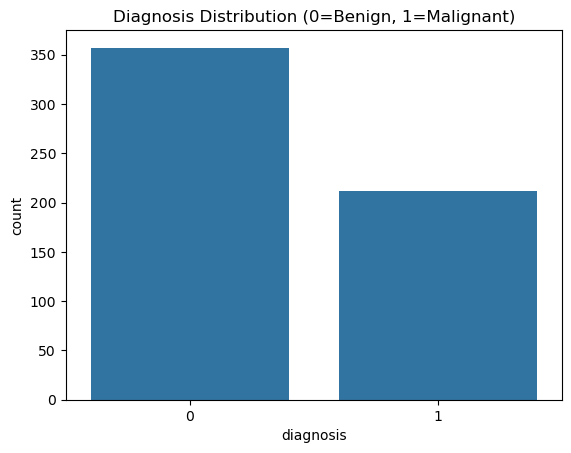

In [132]:
# Distribution of diagnosis for malignant and benign.
sns.countplot(x='diagnosis', data=df)
plt.title('Diagnosis Distribution (0=Benign, 1=Malignant)')
plt.show()

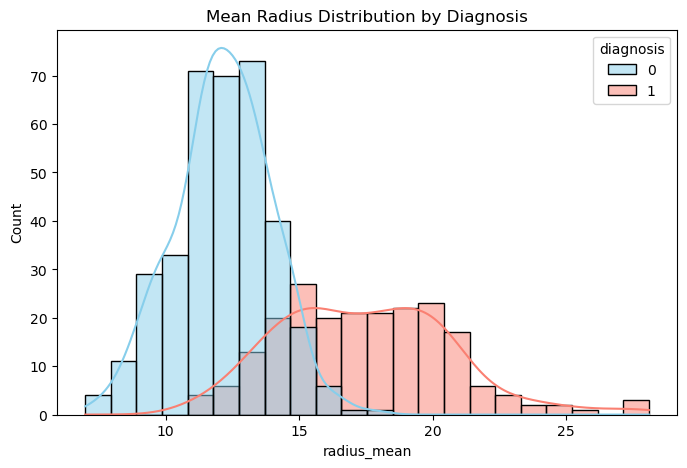

In [133]:
# Distribution of mean radius by diagnosis
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='radius_mean', hue='diagnosis', kde=True, palette={0:'skyblue', 1:'salmon'})
plt.title('Mean Radius Distribution by Diagnosis')
plt.show()

## Correlation analysis

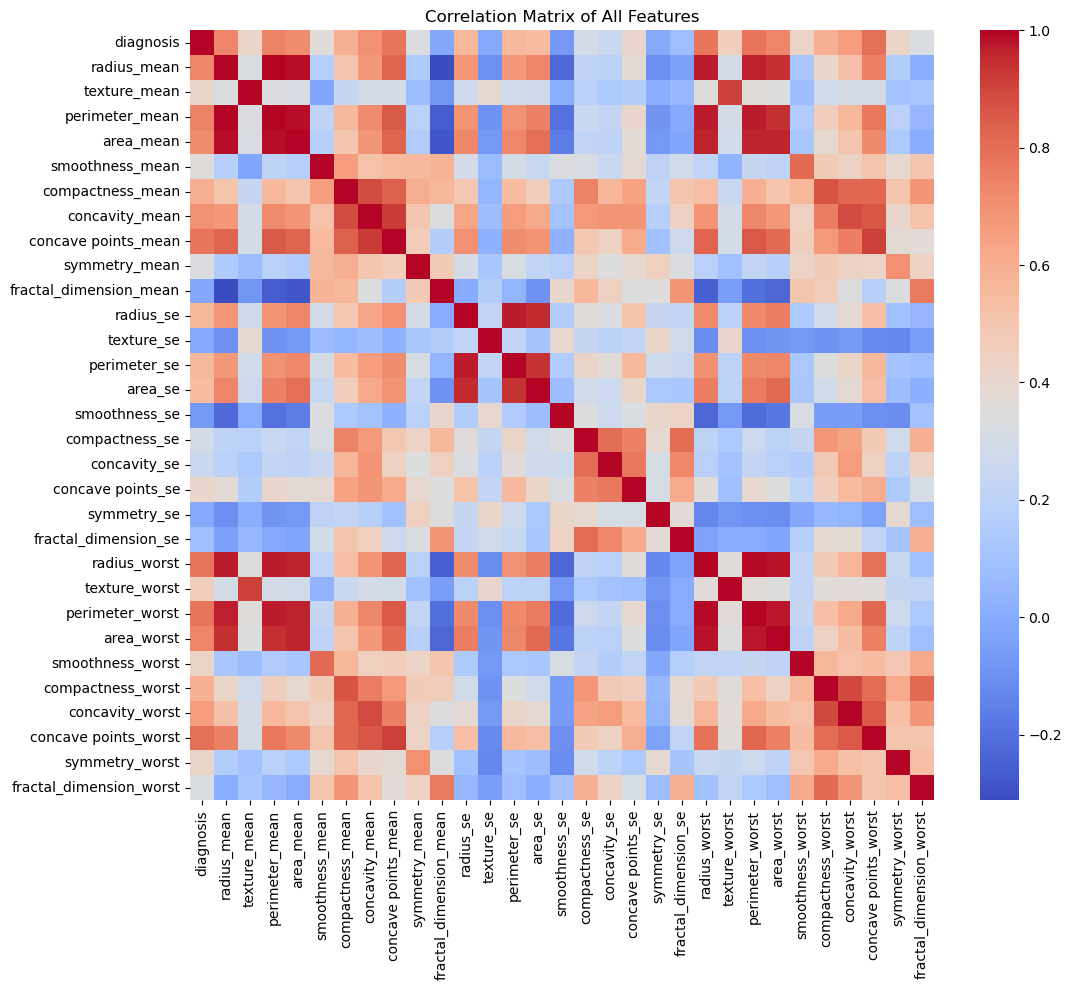

In [134]:
# Correlation heatmap of all numeric features
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Matrix of All Features')
plt.show()

In [135]:
# Correlation of each feature with the diagnosis 
corr_with_target = df.corr()['diagnosis'].sort_values(ascending=False)
print("Top 10 features most positively correlated with malignancy:")
print(corr_with_target.head(10))
print("\nTop 10 features most negatively correlated with malignancy:")
print(corr_with_target.tail(10))

Top 10 features most positively correlated with malignancy:
diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
Name: diagnosis, dtype: float64

Top 10 features most negatively correlated with malignancy:
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0.006522
texture_se                -0.008303
fractal_dimension_mean    -0.012838
smoothness_se             -0.067016
Name: diagnosis, dtype: float64


In [136]:
#From the correlation analysis, features such as 'worst concave points', 'worst perimeter', and 'worst radius' 
#show strong positive correlation with malignancy, which is intuitive
#larger, more irregular tumours tend to be malignant.  
#I will use all 30 features because they all contribute to the model
#but I will also evaluate feature importance later.

## Data Preprocessing

No missing values are present.  
Only scaling is required, because algorithms like SVM and logistic regression are sensitive to feature magnitudes.

In [137]:
# All columns except 'diagnosis' are features
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (569, 30)
Target shape: (569,)


In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training class distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test class distribution:\n{y_test.value_counts(normalize=True)}")

Training set size: (455, 30)
Test set size: (114, 30)
Training class distribution:
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64
Test class distribution:
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


##  Feature Scaling and Comparison of Multiple Classifiers
We will scale the features because many classifiers perform better when features are on a similar scale.
I will review three classifiers using 10‑fold cross‑validation on the training set.
The metric is ROC AUC, which is good to use for an imbalanced classification.

In [139]:
from sklearn.pipeline import Pipeline

In [140]:
from sklearn.model_selection import cross_val_score

# Define pipelines
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True, random_state=42))
    ])
}

# Cross‑validation
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=10, scoring='roc_auc')
    print(f"{name}: Mean CV AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: Mean CV AUC = 0.9953 (+/- 0.0081)
Random Forest: Mean CV AUC = 0.9884 (+/- 0.0185)
SVM: Mean CV AUC = 0.9950 (+/- 0.0079)


## Hyperparameter Tuning
I will tuned the Random Forest classifier because it usually works well without heavy scaling and 
provides feature importances.

In [141]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10]
}

# Pipeline for Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

# Grid search
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV AUC: {:.4f}".format(grid_search.best_score_))

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
Best CV AUC: 0.9906


## Evaluation on the Test Set
Now we use the untouched test set to get a realistic estimate of performance.

Test Set Performance:
Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1 Score:  0.9630
ROC AUC:   0.9940


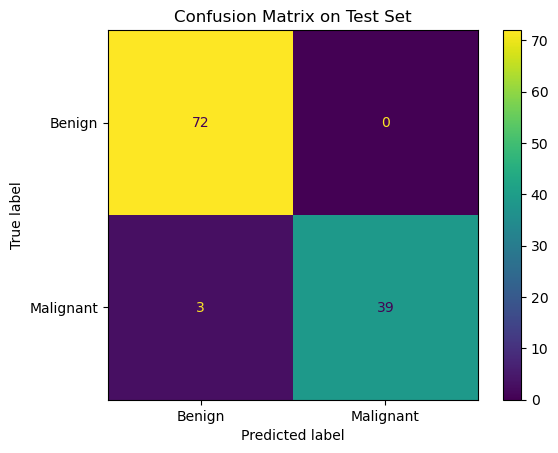

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [142]:
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("Test Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, display_labels=['Benign', 'Malignant'])
plt.title('Confusion Matrix on Test Set')
plt.show()

# Classification report
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

## ROC curve
The ROC curve plots the True Positive Rate  against the False Positive Rate

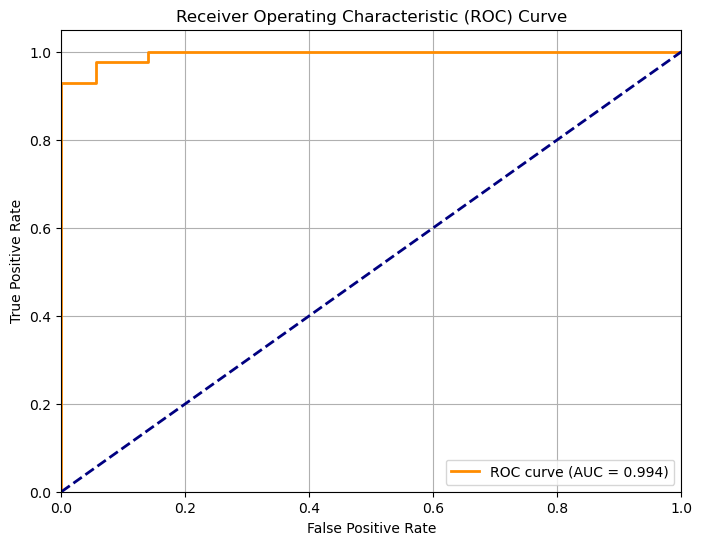

In [145]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Feature Importance for Random Forest
This will help with understanding which measurements are most predictive.

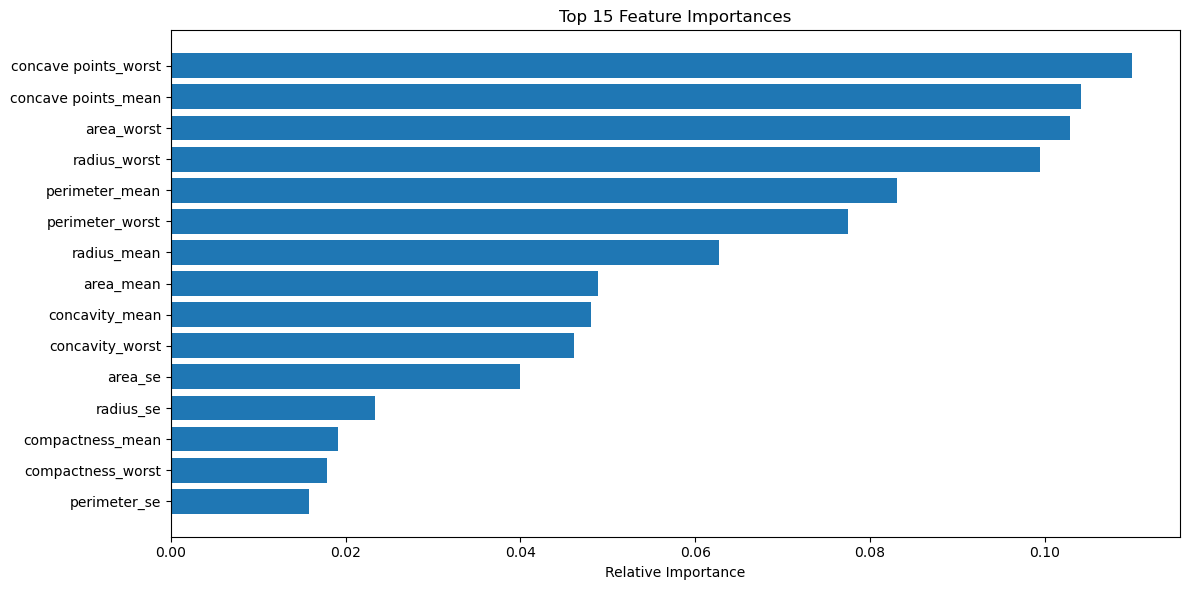

In [146]:
# Extracting the Random Forest classifier from the pipeline
rf_clf = best_rf.named_steps['clf']
importances = rf_clf.feature_importances_
feature_names = X.columns

# Sorting and ploting the top 15
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,6))
plt.title('Top 15 Feature Importances')
plt.barh(range(15), importances[indices[:15]][::-1], align='center')
plt.yticks(range(15), [feature_names[i] for i in indices[:15]][::-1])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

## Predictive Function
Create a function that takes the 30 feature values and returns a diagnosis.

In [147]:
def predict_breast_cancer(features_list):
    """
    features_list : list of 30 numeric values (same order as X columns)
    Returns: 'Malignant' or 'Benign'
    """
    import pandas as pd
    input_df = pd.DataFrame([features_list], columns=X.columns)
    prediction = best_rf.predict(input_df)[0]
    return 'Malignant' if prediction == 1 else 'Benign'

# Example: use the first test sample
sample = X_test.iloc[0].values
print("Sample features (first 5):", sample[:5])
print("Prediction:", predict_breast_cancer(sample))
print("Actual:", 'Malignant' if y_test.iloc[0]==1 else 'Benign')

Sample features (first 5): [1.141e+01 1.082e+01 7.334e+01 4.033e+02 9.373e-02]
Prediction: Benign
Actual: Benign
